In [1]:
import numpy as np
from scipy import linalg
import pandas as pd
import matplotlib.pyplot as plt

Convert a list datatype of 1D to 2D and 3D using numpy

In [ ]:
user_input = list(map(int, input("Enter numbers: ").split()))
arr = np.array(user_input)

rows = 2  # you decide this
arr_2d = arr.reshape(rows, -1)

print(arr_2d)

ValueError: cannot reshape array of size 3 into shape (2,newaxis)

Generate random matrices using numpy of all dimensions

In [80]:
def random_matrix(shape,low,high):
    # return low+(high-low) * np.random.rand(*shape)
    return np.random.randint(low, high, size=shape)

print(random_matrix((2,3,4),10,100))

[[[37 90 94 35]
  [58 70 30 41]
  [48 28 44 67]]

 [[12 59 94 24]
  [22 42 59 16]
  [26 92 71 95]]]


Find determinant of a matrix using scipy

In [78]:
arr = eval(input("Enter arr: "))
A = np.array(arr)

print(linalg.det(A))

-6.0


Find the eig value and eig vector of a matrix for all dimension

In [86]:
arr = eval(input("Enter arr: "))
A = np.array(arr)

eigenval,eigenvec = linalg.eig(A)

print("Eigenvalues: ",eigenval)
print("Eigenvector: ",eigenvec)

Eigenvalues:  [-0.37228132+0.j  5.37228132+0.j]
Eigenvector:  [[-0.82456484 -0.41597356]
 [ 0.56576746 -0.90937671]]


Declare series data and index name o/p one inf and one nan

In [4]:
data = [10,np.inf,np.nan,40]
index = ['a','b','c','d']

s = pd.Series(data,index=index)
s

a    10.0
b     inf
c     NaN
d    40.0
dtype: float64

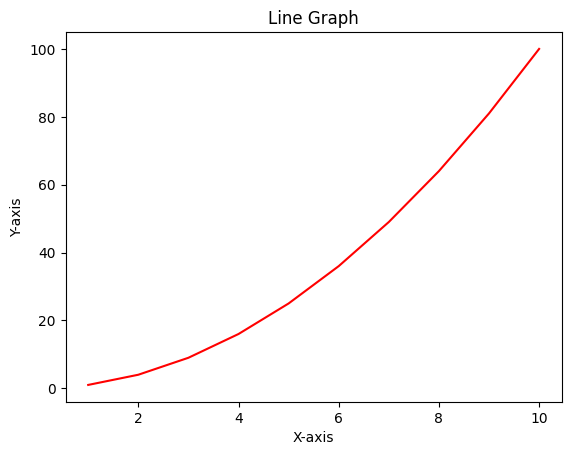

In [16]:
x = [1, 2, 3, 4,5,6,7,8,9,10]
y = [1, 4, 9, 16,25,36,49,64,81,100]

plt.plot(x,y,color='red')
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Line Graph")
plt.show()

In [34]:
data = {
    "Roll": [1,2,3,4,5,6,7,8,9,10],
    "Name": ["A","B","C","D","E","F","G","H","I","J"],
    "Branch": ["CSE","IT","ECE","ME","CE","CSE","IT","ECE","ME","CE"],
    "Marks": [80, 75, 90, 60, 85, 78, 88, 92, 70, 81],
    "Attendance": [90, 85, 88, 70, 95, 80, 87, 93, 75, 89]
}

df = pd.DataFrame(data)
df.set_index("Roll",inplace=True)

df.head()
df.shape

filtered_df = df[(df["Marks"]>78) & (df["Attendance"]>85)]
sorted_df = filtered_df.sort_values(by=["Marks","Attendance"],ascending=[False,False])
sorted_df

,Name,Branch,Marks,Attendance
Roll,,,,
8,H,ECE,92,93
3,C,ECE,90,88
7,G,IT,88,87
5,E,CE,85,95
10,J,CE,81,89
1,A,CSE,80,90


Plot y=x^2

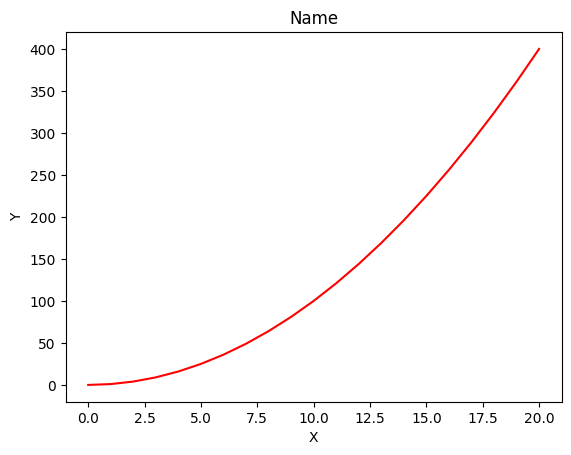

In [44]:
x = []
y = []

for i in range(0,21):
    x.append(i)
    y.append(i**2)

plt.plot(x,y,color='red')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Name")
plt.show()

y=3x+noise

(-6.2404890230293155, 36.4968737552408)

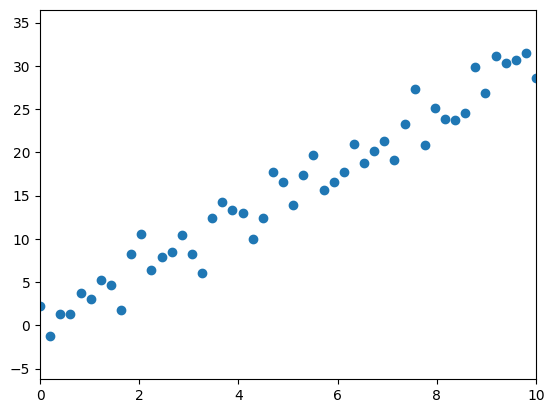

In [29]:
x = np.linspace(0, 10, 50)
noise = np.random.randn(50)*2

y = 3*x+noise
plt.scatter(x,y)

plt.xlim(0,10)
plt.ylim(min(y)-5,max(y)+5)

2*2 sub-plot showing line plot, bar plot, histogram, scatter plot

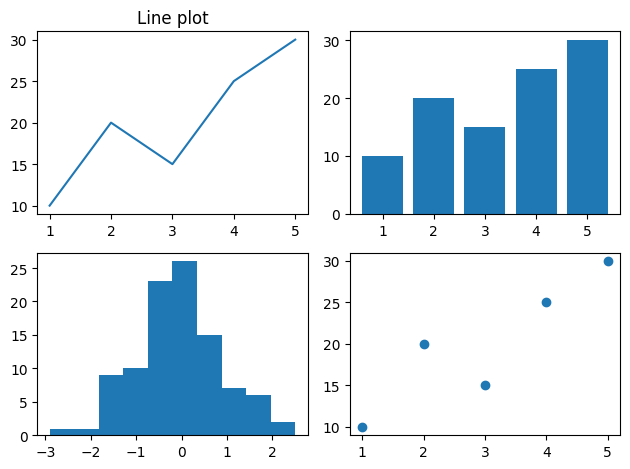

In [ ]:
x = np.arange(1, 6)
y = [10, 20, 15, 25, 30]

fig,axs = plt.subplots(2,2)
data = np.random.randn(100)


axs[0,0].plot(x,y)
axs[0,0].set_title("Line plot")
axs[0,1].bar(x,y)
axs[1,0].hist(data,bins=10)
axs[1,1].scatter(x,y)

plt.tight_layout()
plt.show()

Load iris dataset

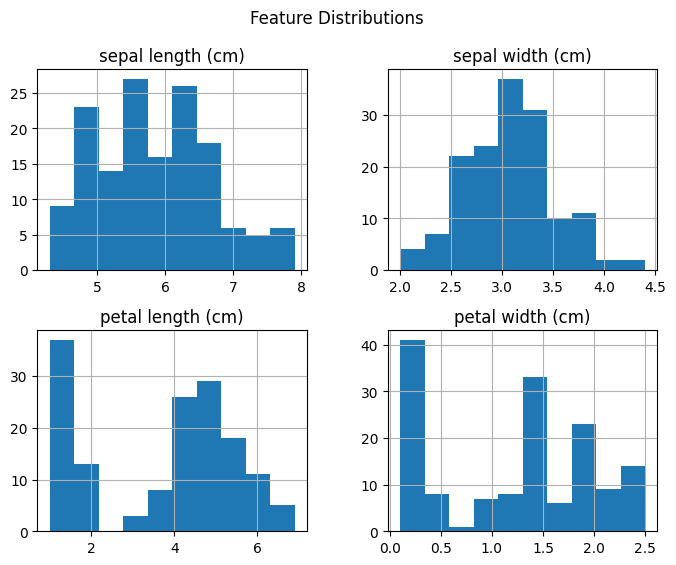

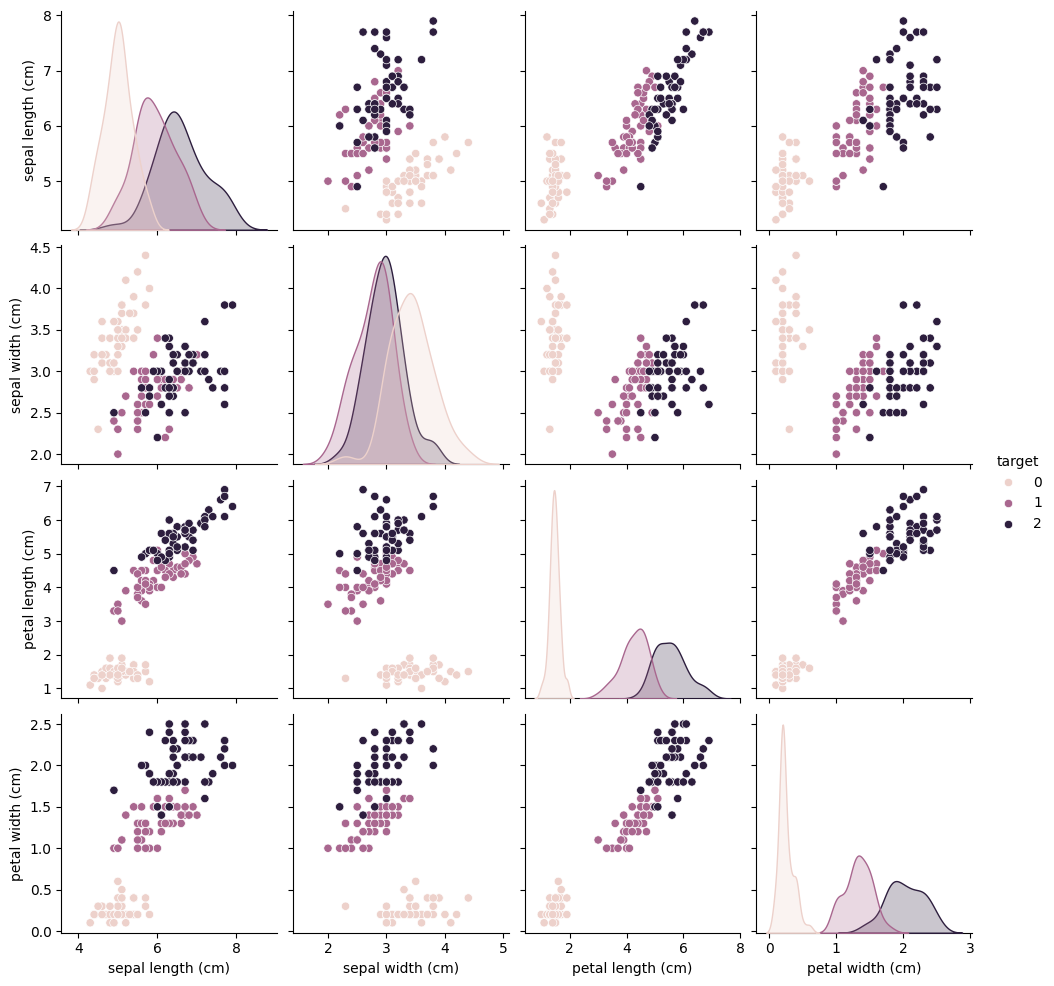

In [14]:
from sklearn.datasets import load_iris
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import pandas as pd

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

# Features and target
X = df.drop('target',axis=1)
y = df['target']

# Scaling
scalar = StandardScaler()
x_scaled = scalar.fit_transform(X)
x_scaled = pd.DataFrame(x_scaled,columns=X.columns)
x_scaled.head()

# Visualisation
X.hist(figsize=(8,6))
plt.suptitle("Feature Distributions")
plt.show()
# Better plots
sns.pairplot(df, hue='target')
plt.show()

California Housing dataset

In [43]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
import pandas as pd

data = fetch_california_housing()
df = pd.DataFrame(data.data,columns=data.feature_names)
df['target'] = data.target
# df.head()

# Splitting data
X = df.drop('target',axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scaling data
scalar = StandardScaler()
X_trained_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

# Simple regression
X_train_simple = X_train[['MedInc']]
X_test_simple = X_test[['MedInc']]
model_simple = LinearRegression()
model_simple.fit(X_train_simple,y_train)
y_pred_simple = model_simple.predict(X_test_simple)
mse_simple = mean_squared_error(y_test,y_pred_simple)

# Multiple regression
model_multi = LinearRegression()
model_multi.fit(X_trained_scaled,y_train)
y_pred = model_multi.predict(X_test_scaled)
mse_multi = mean_squared_error(y_test, y_pred)

# Polynomial regression
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
model_poly = LinearRegression()
model_poly.fit(X_train_poly,y_train)
y_pred_poly = model_poly.predict(X_test_poly)
mse_poly = mean_squared_error(y_test,y_pred_poly)

print("MSE simple: ",mse_simple)
print("MSE multi: ",mse_multi)
print("MSE poly: ",mse_poly)

MSE simple:  0.7091157771765548
MSE multi:  0.5558915986952444
MSE poly:  0.4643015267299938


Breast Cancer dataset

In [60]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix
import pandas as pd

data = load_breast_cancer()
df = pd.DataFrame(data=data.data,columns=data.feature_names)
df['target'] = data.target
X = df.drop('target',axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

model = LogisticRegression(max_iter=100)
model.fit(X_train_scaled,y_train)
y_pred = model.predict(X_test_scaled)
# acc = accuracy_score(y_test,y_pred)
# acc
cm = confusion_matrix(y_test,y_pred)
# cm
TN, FP, FN, TP = cm.ravel()
TPR = TP / (TP + FN)
TNR = TN / (TN + FP)
FPR = FP / (FP + TN)
FNR = FN / (FN + TP)
print("TPR (Recall):", TPR)
print("TNR (Specificity):", TNR)
print("FPR:", FPR)
print("FNR:", FNR)

TPR (Recall): 0.9859154929577465
TNR (Specificity): 0.9534883720930233
FPR: 0.046511627906976744
FNR: 0.014084507042253521


Create Boolean datasets for AND, OR, and XOR operations

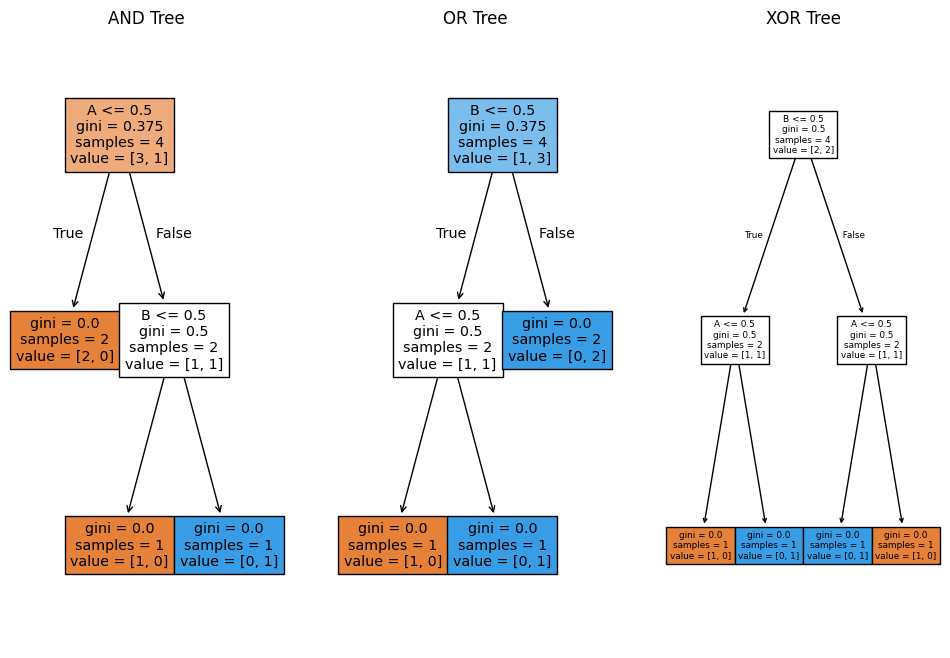

In [7]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier,plot_tree
import matplotlib.pyplot as plt

X = pd.DataFrame({
    "A":[0,0,1,1],
    "B":[0,1,0,1]
})

y_and = [0,0,0,1]
y_or = [0,1,1,1]
y_xor = [0,1,1,0]

model_and = DecisionTreeClassifier()
model_or = DecisionTreeClassifier()
model_xor = DecisionTreeClassifier()

model_and.fit(X,y_and)
model_or.fit(X, y_or)
model_xor.fit(X, y_xor)

plt.figure(figsize=(12,8))
plt.subplot(1,3,1)
plot_tree(model_and, feature_names=["A","B"], filled=True)
plt.title("AND Tree")
plt.subplot(1,3,2)
plot_tree(model_or, feature_names=["A","B"], filled=True)
plt.title("OR Tree")
plt.subplot(1,3,3)
plot_tree(model_xor, feature_names=["A","B"], filled=True)
plt.title("XOR Tree")
plt.show()

Wine dataset

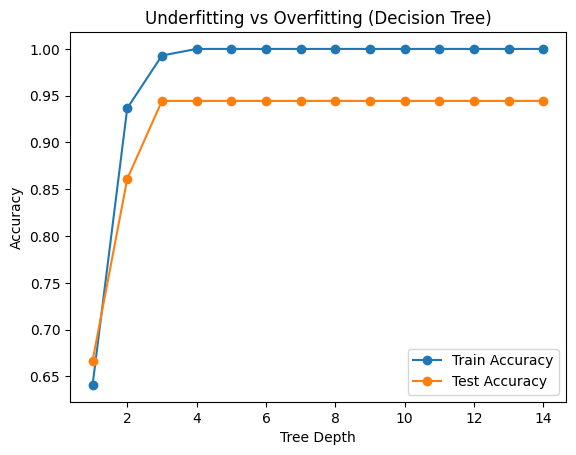

In [8]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

data = load_wine()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

train_acc = []
test_acc = []
depths = range(1,15)
for d in depths:
    model = DecisionTreeClassifier(max_depth=d,random_state=42)
    model.fit(X_train,y_train)
    train_acc.append(model.score(X_train,y_train))
    test_acc.append(model.score(X_test, y_test))

plt.plot(depths, train_acc, label="Train Accuracy", marker='o')
plt.plot(depths, test_acc, label="Test Accuracy", marker='o')
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Underfitting vs Overfitting (Decision Tree)")
plt.legend()

plt.show()

K-Nearest Neighbour (KNN) classification on the Iris dataset

In [ ]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import time

data = load_iris()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=46
)

model = KNeighborsClassifier(n_neighbors=5)
start = time.time()
model.fit(X_train,y_train)
train_time = time.time() - start
print("Training Time:", train_time)
start = time.time()
y_pred = model.predict(X_test)
predict_time = time.time() - start
print("Prediction Time:", predict_time)
acc = accuracy_score(y_test,y_pred)
print("Accuracy:", acc)

Training Time: 0.0010094642639160156
Prediction Time: 0.0016531944274902344
Accuracy: 0.9333333333333333


Train a Naïve Bayes classifier using a categorical dataset such as the Play Tennis 
dataset. Encode categorical attributes and predict the class label for new samples. 

In [7]:
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import CategoricalNB
import pandas as pd
data = {
    'Outlook' : ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal'],
    'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak'],
    'PlayTennis': ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes']
}

df = pd.DataFrame(data)
encoders={}
for col in df.columns[:-1]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

target_encoder = LabelEncoder()
df['PlayTennis'] = target_encoder.fit_transform(df['PlayTennis'])

pred_data = {
    'Outlook': ['Sunny'],
    'Temperature': ['Cool'],
    'Humidity': ['High'],
    'Wind': ['Strong']
}

X_test = pd.DataFrame(pred_data)
for col in X_test.columns:
    X_test[col] = encoders[col].transform(X_test[col])

X = df.drop('PlayTennis',axis=1)
y = df['PlayTennis']

model = CategoricalNB()
model.fit(X,y)

print(model.predict(X_test))

X_test

[0]


,Outlook,Temperature,Humidity,Wind
0,2,0,0,0


Perceptron from scratch

In [8]:
import numpy as np

def unit_step_func(x):
    return np.where(x>0, 1, 0)

class Perceptron:
    def __init__(self,learning_rate=0.01,n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.activation_func = unit_step_func
        self.weights = None
        self.bias = None
    
    def fit(self,X,y):
        n_samples,n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        # y must be between 0 and 1
        y_ = np.where(y>0,1,0)

        for _ in range(self.n_iters):
            for idx,x_i in enumerate(X):
                linear_output = np.dot(x_i,self.weights) + self.bias
                y_predicted = unit_step_func(linear_output)
                # updation
                update = self.lr * (y_[idx] - y_predicted)
                self.weights += update * x_i
                self.bias += update

    def predict(self,X):
        linear_output = np.dot(X,self.weights) + self.bias
        y_predicted = unit_step_func(linear_output)
        return y_predicted

X_and = np.array([[0,0],[0,1],[1,0],[1,1]])
y_and = np.array([0,0,0,1])

model = Perceptron(learning_rate=0.01, n_iters=1000)
model.fit(X_and, y_and)

print("AND Predictions:", model.predict(X_and))

X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([0,1,1,0])

model = Perceptron(learning_rate=0.01, n_iters=1000)
model.fit(X_xor, y_xor)

print("XOR Predictions:", model.predict(X_xor))

AND Predictions: [0 0 0 1]
XOR Predictions: [1 1 0 0]


Train Decision Tree, Random Forest, and AdaBoost models on the Breast Cancer 
dataset

In [5]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)

rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

ab = AdaBoostClassifier(n_estimators=100,random_state=42)
ab.fit(X_train,y_train)

y_dt = dt.predict(X_test)
y_rf = rf.predict(X_test)
y_ab = ab.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_rf))
print("AdaBoost Accuracy:", accuracy_score(y_test, y_ab))

Decision Tree Accuracy: 0.9473684210526315
Random Forest Accuracy: 0.9649122807017544
AdaBoost Accuracy: 0.9736842105263158


Imbalanced classification dataset

In [8]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_classes=2,
    weights=[0.95, 0.05],   # 95% class 0, 5% class 1
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

Accuracy: 0.945
Precision: 0.6666666666666666
Recall: 0.16666666666666666
F1 Score: 0.26666666666666666


PCA on the Wine dataset (also check scratch impl)

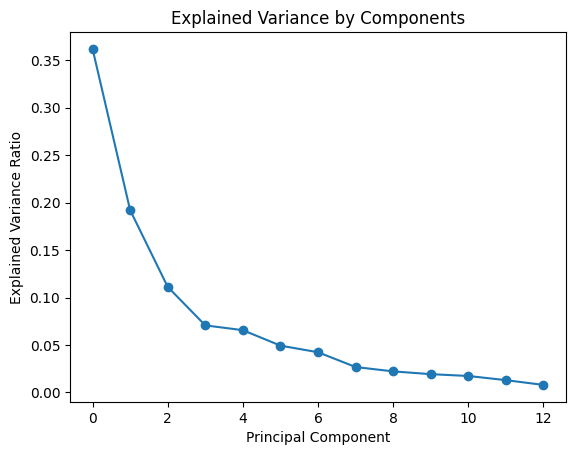

Reduced Shape: (178, 2)


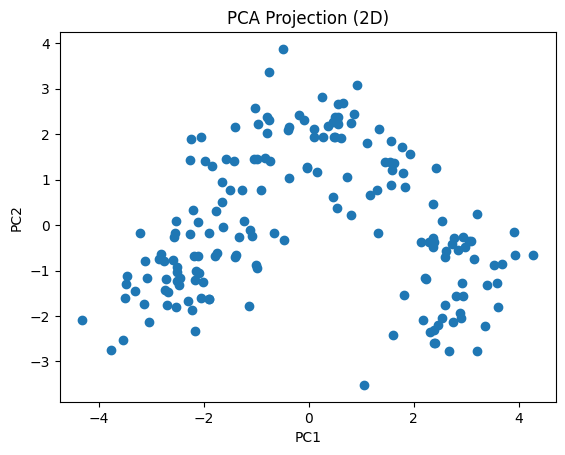

In [4]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

data = load_wine()
X = data.data
scalar = StandardScaler()
X_scaled  = scalar.fit_transform(X)
cov_matrix = np.cov(X_scaled, rowvar=False)

eigenval,eigenvec = np.linalg.eig(cov_matrix)
# print("Eigenvalues:\n", eigenval)
# print("\nEigenvectors:\n", eigenvec)

sorted_idx = np.argsort(eigenval)[::-1]
eigenvalues = eigenval[sorted_idx]
eigenvectors = eigenvec[:, sorted_idx]

explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
# print("Explained Variance Ratio:\n", explained_variance_ratio)

plt.plot(explained_variance_ratio, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Components")
plt.show()

k = 2
W = eigenvectors[:, :k]
X_reduced = np.dot(X_scaled, W)
print("Reduced Shape:", X_reduced.shape)
plt.scatter(X_reduced[:,0], X_reduced[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (2D)")
plt.show()

Explained variance ratio: [0.36198848 0.1920749 ]
Total variance retained: 0.5540633835693526


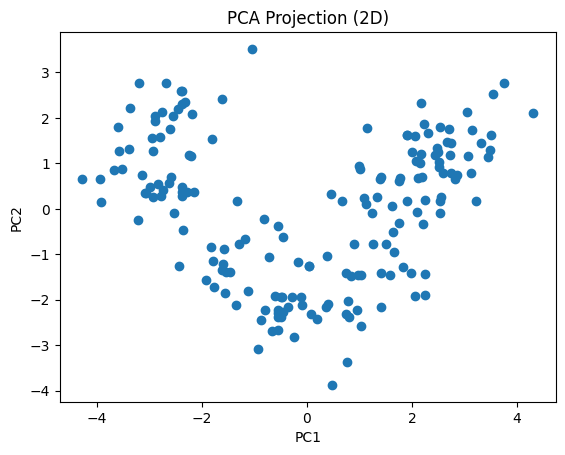

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load data
data = load_wine()
X = data.data

# Step 1: Standardize (MANDATORY for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: Apply PCA
pca = PCA(n_components=2)   # reduce to 2 dimensions
X_pca = pca.fit_transform(X_scaled)

# Step 3: Explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance retained:", np.sum(pca.explained_variance_ratio_))

# Step 4: Plot
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (2D)")
plt.show()

Perform K-means clustering on the Iris dataset 

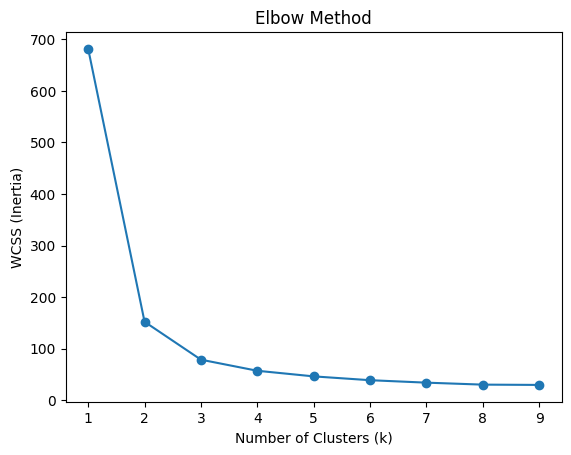

In [6]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

data = load_iris()
X = data.data   # ignore labels

inertia = []
K_range = range(1,10)

for k in K_range:
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method")
plt.show()

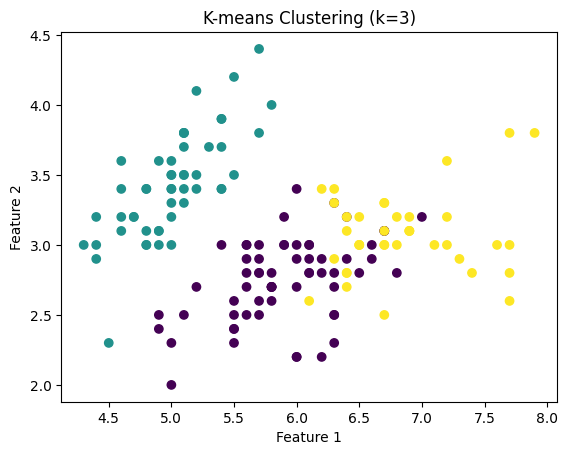

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-means Clustering (k=3)")
plt.show()

Synthetic Data Creation

Linear Data Accuracy: 0.6
Non-linear Data Accuracy: 0.9
Noisy Data Accuracy: 0.90625


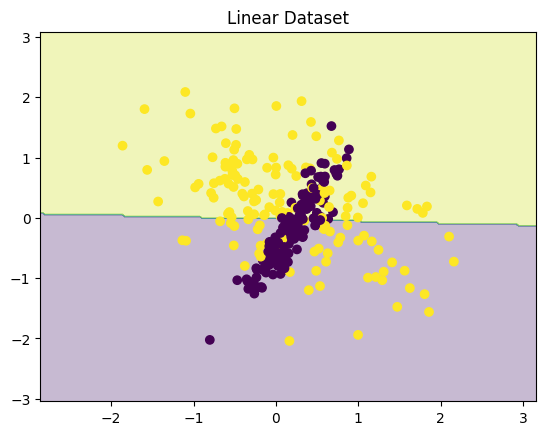

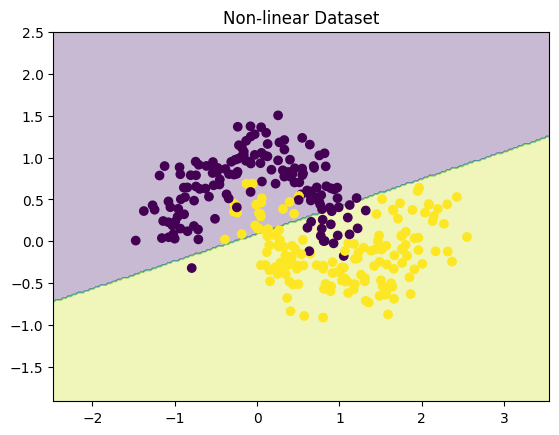

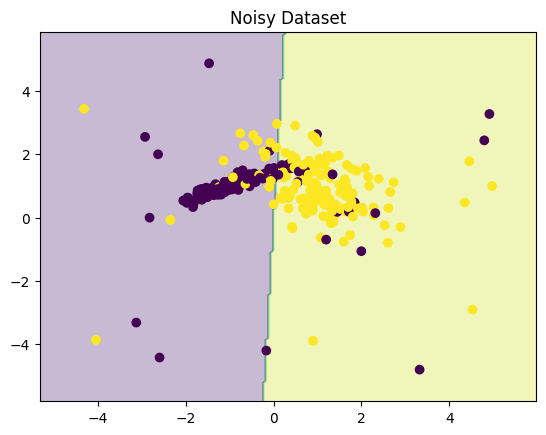

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Linearly separable
X1,y1 = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=0.2,
    random_state=42
)

X2, y2 = make_moons(n_samples=300, noise=0.2, random_state=42)

X3, y3 = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.0,
    flip_y=0.1,   # label noise
    random_state=42
)

outliers = np.random.uniform(low=-5, high=5, size=(20,2))
labels_out = np.random.randint(0,2,20)
X3 = np.vstack([X3, outliers])
y3 = np.hstack([y3, labels_out])

def train_and_eval(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    model = LogisticRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    return model, accuracy_score(y_test, y_pred)
model1, acc1 = train_and_eval(X1, y1)
model2, acc2 = train_and_eval(X2, y2)
model3, acc3 = train_and_eval(X3, y3)
print("Linear Data Accuracy:", acc1)
print("Non-linear Data Accuracy:", acc2)
print("Noisy Data Accuracy:", acc3)

def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y)
    plt.title(title)
    plt.show()

plot_decision_boundary(model1, X1, y1, "Linear Dataset")
plot_decision_boundary(model2, X2, y2, "Non-linear Dataset")
plot_decision_boundary(model3, X3, y3, "Noisy Dataset")

Q Learning

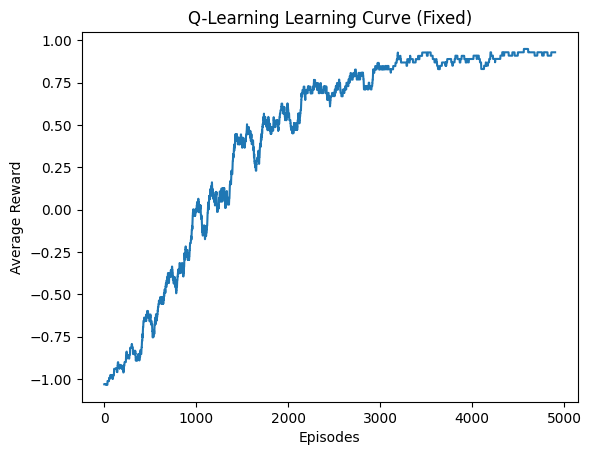

Total Successes: 3657

Learned Policy (0=←,1=↓,2=→,3=↑):
[[2 2 1 0]
 [3 0 1 0]
 [3 0 1 0]
 [0 2 2 0]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. GRID WORLD SETUP
# -----------------------------
n = 4

goal = 15
holes = [5, 7, 11, 12,3,9]
actions = [0, 1, 2, 3]  # left, down, right, up

# -----------------------------
# 2. STEP FUNCTION (UPDATED)
# -----------------------------
def step(state, action):
    row, col = divmod(state, n)

    if action == 0: col = max(col - 1, 0)
    elif action == 1: row = min(row + 1, n - 1)
    elif action == 2: col = min(col + 1, n - 1)
    elif action == 3: row = max(row - 1, 0)

    next_state = row * n + col

    # ✅ Reward shaping
    if next_state in holes:
        return next_state, -1, True
    elif next_state == goal:
        return next_state, 1, True
    else:
        return next_state, -0.01, False


# -----------------------------
# 3. Q-TABLE INITIALIZATION
# -----------------------------
Q = np.zeros((n * n, 4))

# -----------------------------
# 4. HYPERPARAMETERS
# -----------------------------
alpha = 0.1
gamma = 0.9

epsilon = 1.0
epsilon_decay = 0.999
epsilon_min = 0.01

episodes = 5000
max_steps = 100

rewards = []

# -----------------------------
# 5. TRAINING LOOP
# -----------------------------
for ep in range(episodes):
    state = np.random.choice()
    total_reward = 0

    for _ in range(max_steps):

        # ε-greedy policy
        if np.random.rand() < epsilon:
            action = np.random.choice(actions)
        else:
            action = np.argmax(Q[state])

        next_state, reward, done = step(state, action)

        # Q-learning update
        Q[state, action] += alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )

        state = next_state
        total_reward += reward

        if done:
            break

    # decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    rewards.append(total_reward)


# -----------------------------
# 6. SMOOTH REWARD (IMPORTANT)
# -----------------------------
def moving_average(data, window=100):
    return np.convolve(data, np.ones(window)/window, mode='valid')

smoothed = moving_average(rewards)

# -----------------------------
# 7. PLOT
# -----------------------------
plt.plot(smoothed)
plt.xlabel("Episodes")
plt.ylabel("Average Reward")
plt.title("Q-Learning Learning Curve (Fixed)")
plt.show()


# -----------------------------
# 8. RESULTS
# -----------------------------
print("Total Successes:", sum([1 for r in rewards if r > 0]))

policy = np.argmax(Q, axis=1)
print("\nLearned Policy (0=←,1=↓,2=→,3=↑):")
print(policy.reshape(n, n))

k-fold validation

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import numpy as np

# -----------------------------
# 1. LOAD DATA
# -----------------------------
data = load_breast_cancer()
X = data.data
y = data.target

# -----------------------------
# 2. MODEL PIPELINE (IMPORTANT)
# -----------------------------
model = LogisticRegression(max_iter=5000)

# -----------------------------
# 3. SINGLE TRAIN-TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print("Train-Test Accuracy:", test_accuracy)

# -----------------------------
# 4. K-FOLD CROSS VALIDATION
# -----------------------------
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

cv_scores = cross_val_score(model, X, y, cv=kf, scoring="accuracy")

print("\nK-Fold Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))
print("Std Dev (Stability):", np.std(cv_scores))

Train-Test Accuracy: 0.956140350877193

K-Fold Accuracy Scores: [0.95614035 0.96491228 0.93859649 0.97368421 0.92035398]
Mean CV Accuracy: 0.9507374631268437
Std Dev (Stability): 0.019116636583291855


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("Titanic-Dataset.csv")

# Drop unnecessary columns
df = df.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

# Handle missing values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Fare"] = df["Fare"].fillna(df["Fare"].median())

# Encode categorical columns
sex_encoder = LabelEncoder()
embarked_encoder = LabelEncoder()

df["Sex"] = sex_encoder.fit_transform(df["Sex"])
df["Embarked"] = embarked_encoder.fit_transform(df["Embarked"])

# Features and target
X = df.drop("Survived", axis=1)
y = df["Survived"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score

df = pd.read_csv('adult.csv')
# data.columns
df.replace('?',np.nan,inplace=True)

df['workclass'] = df['workclass'].fillna(df['workclass'].mode()[0])
df['occupation'] = df['occupation'].fillna(df['occupation'].mode()[0])
df['native.country'] = df['native.country'].fillna(df['native.country'].mode()[0])
df.isnull().sum()

ohe = OneHotEncoder()

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('income',axis=1)
y = df['income']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,random_state=42,test_size=0.2,stratify=y
)

scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

# model = LogisticRegression(max_iter=15000)
# model.fit(X_train_scaled,y_train)
# y_pred = model.predict(X_test_scaled)

base_model = DecisionTreeClassifier(max_depth=10)
model = AdaBoostClassifier(estimator=base_model,n_estimators=200)
model.fit(X_train_scaled,y_train)
y_pred = model.predict(X_test_scaled)

print("Accuracy: ",accuracy_score(y_test,y_pred))
print("Recall: ",recall_score(y_test,y_pred))
print("Precision: ",precision_score(y_test,y_pred))
print("F1 score: ",f1_score(y_test,y_pred))